# Paper 02 — Blandhol, Bonney, Mogstad & Torgovitsky: *When is TSLS Actually LATE?*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/afrtrivi1120/causal-inference-papers-explainer/blob/master/papers/iv/02-blandhol-bonney-mogstad-torgovitsky-tsls-late/simulation.ipynb)

See this folder's `README.md` for the 12-section explainer. This notebook is the runnable companion.

**What this simulation shows.** When the instrument $Z$ is only valid *conditional on* a covariate $X$ — and compliance + LATEs vary across strata of $X$ — the common empirical recipe

$$ Y \sim D + X \mid Z + X $$

does **not** recover a non-negatively-weighted average of the stratum LATEs. A **saturated** specification that interacts $Z$ with $X$ does.

**Why conditional randomization matters.** If $Z$ were marginally independent of $X$, the unsaturated Wald would already equal the population LATE and there would be no bias. The Blandhol et al. critique hits the common case where $Z$ is only valid *once you condition on* $X$ — controlling for $X$ linearly is not enough.

**DGP highlights.**

- $X \sim \mathrm{Bernoulli}(0.5)$.
- $Z\,|\,X=0 \sim \mathrm{Bernoulli}(0.15)$; $Z\,|\,X=1 \sim \mathrm{Bernoulli}(0.55)$.
- $X=0$: complier share 0.20, stratum LATE = 3.0 (big effect, few compliers)
- $X=1$: complier share 0.60, stratum LATE = 0.0 (no effect, many compliers)
- Population LATE (target estimand, weighted by complier mass): $(0.10 \cdot 3.0 + 0.30 \cdot 0.0)/0.40 = 0.75$.

In [1]:
# Suppress anaconda-local UserWarnings before any import that touches pandas internals.
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# Colab: pre-installed stack is sufficient except for linearmodels.
# Locally: `pip install -r requirements.txt` from the repo root first.
try:
    import linearmodels
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'linearmodels>=6.0'])
    import linearmodels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from linearmodels.iv import IV2SLS

SEED = 20260421
rng = np.random.default_rng(SEED)

import sys, statsmodels
print(f'Python        {sys.version.split()[0]}')
print(f'numpy         {np.__version__}')
print(f'pandas        {pd.__version__}')
print(f'matplotlib    {plt.matplotlib.__version__}')
print(f'statsmodels   {statsmodels.__version__}')
print(f'linearmodels  {linearmodels.__version__}')

Python        3.11.5
numpy         1.26.4
pandas        3.0.2
matplotlib    3.10.8
statsmodels   0.14.6
linearmodels  7.0


## Parameters

In [2]:
N_SIM = 500
N     = 5000

# Compliance-type mix (always-taker, never-taker, complier), no defiers.
probs_X0 = np.array([0.10, 0.70, 0.20])   # always, never, complier
probs_X1 = np.array([0.10, 0.30, 0.60])

# P(Z=1 | X). Asymmetric on purpose — symmetric pZ would give identical
# Var(Z|X) across strata and unsaturated TSLS would coincidentally get
# the right LATE by accident. We want the weighting bug to be visible.
pZ_X0 = 0.15
pZ_X1 = 0.55

# Stratum-specific constant treatment effects.
tau_X0 = 3.0
tau_X1 = 0.0

# Population LATE, weighting by complier MASS:
#   mass_X0 = P(X=0) * complier share X=0 = 0.5 * 0.20 = 0.10
#   mass_X1 = P(X=1) * complier share X=1 = 0.5 * 0.60 = 0.30
true_LATE = (0.10 * tau_X0 + 0.30 * tau_X1) / (0.10 + 0.30)   # = 0.75
print(f'true population LATE = {true_LATE}')

true population LATE = 0.7500000000000001


## One Monte Carlo draw

Draw `(X, Z, type)`, build `D` from `(type, Z)`, realize `Y` given `D` and the stratum's constant treatment effect. Fit three estimators:

1. **Unsaturated TSLS:** `Y ~ D + X | Z + X`. This is the common practitioner recipe.
2. **Stratum-Wise Wald** pooled by estimated complier mass — the cleanest target-parameter estimator given a binary `X`.
3. **Full-interaction TSLS:** `Y ~ D + X + D:X | Z + X + Z:X`. Saturates the first stage; recovers stratum LATEs which we then aggregate by complier mass.

In [3]:
TYPES = np.array(['always', 'never', 'complier'])

def run_once(rng):
    X = rng.binomial(1, 0.5, N)
    # Z is conditionally random given X, not marginally random
    Z = rng.binomial(1, np.where(X == 0, pZ_X0, pZ_X1))

    # Compliance type per unit, conditional on X
    type_ = np.empty(N, dtype=object)
    mask0 = (X == 0)
    mask1 = (X == 1)
    type_[mask0] = rng.choice(TYPES, size=mask0.sum(), p=probs_X0)
    type_[mask1] = rng.choice(TYPES, size=mask1.sum(), p=probs_X1)

    D = ((type_ == 'always') | ((type_ == 'complier') & (Z == 1))).astype(int)

    eps = rng.normal(0, 1, N)
    tau = np.where(X == 0, tau_X0, tau_X1)
    Y   = np.where(D == 1, tau + eps, eps)

    df = pd.DataFrame({'Y': Y, 'D': D, 'Z': Z, 'X': X})

    # ---- Estimator 1: unsaturated TSLS: Y ~ D + X | Z + X --------------
    fit_unsat = IV2SLS(
        dependent=df['Y'],
        exog=pd.DataFrame({'const': 1.0, 'X': df['X']}),
        endog=df[['D']],
        instruments=df[['Z']],
    ).fit(cov_type='unadjusted')
    est_unsat = float(fit_unsat.params['D'])

    # ---- Estimator 2: stratum Wald, pooled by complier mass -------------
    def wald(sub):
        num = sub.loc[sub['Z'] == 1, 'Y'].mean() - sub.loc[sub['Z'] == 0, 'Y'].mean()
        den = sub.loc[sub['Z'] == 1, 'D'].mean() - sub.loc[sub['Z'] == 0, 'D'].mean()
        return {'num': num, 'den': den, 'wald': num / den, 'size': len(sub)}

    w0 = wald(df[df['X'] == 0])
    w1 = wald(df[df['X'] == 1])
    mass0 = (w0['size'] / N) * w0['den']
    mass1 = (w1['size'] / N) * w1['den']
    est_sat = (mass0 * w0['wald'] + mass1 * w1['wald']) / (mass0 + mass1)

    # ---- Estimator 3: full-interaction TSLS, pooled by complier mass ----
    # Y ~ D + X + D:X | Z + X + Z:X saturates the first stage.
    # Complier-mass weights come from the stratum Wald first stage above —
    # this mix-and-match works cleanly because X is binary and N is large.
    df2 = df.assign(DX=df['D'] * df['X'], ZX=df['Z'] * df['X'])
    fit_int = IV2SLS(
        dependent=df2['Y'],
        exog=pd.DataFrame({'const': 1.0, 'X': df2['X']}),
        endog=df2[['D', 'DX']],
        instruments=df2[['Z', 'ZX']],
    ).fit(cov_type='unadjusted')
    tau0_hat = float(fit_int.params['D'])
    tau1_hat = float(fit_int.params['D'] + fit_int.params['DX'])
    est_full = (mass0 * tau0_hat + mass1 * tau1_hat) / (mass0 + mass1)

    return {
        'unsat':    est_unsat,
        'sat_wald': est_sat,
        'full_int': est_full,
        'wald_X0':  w0['wald'],
        'wald_X1':  w1['wald'],
    }

## Monte Carlo

In [4]:
print(f'Running {N_SIM} Monte Carlo draws (N = {N}) ... ', end='', flush=True)
rows = [run_once(rng) for _ in range(N_SIM)]
results = pd.DataFrame(rows)
print('done.')

summary = pd.DataFrame({
    'estimator':     ['Unsaturated TSLS (Y ~ D + X | Z + X)',
                      'Saturated: stratum Wald, pooled by complier mass',
                      'Saturated: full interaction TSLS, pooled',
                      'Stratum Wald at X=0 only',
                      'Stratum Wald at X=1 only'],
    'truth':         [true_LATE, true_LATE, true_LATE, tau_X0, tau_X1],
    'mean_estimate': [results['unsat'].mean(), results['sat_wald'].mean(), results['full_int'].mean(),
                      results['wald_X0'].mean(), results['wald_X1'].mean()],
    'mc_sd':         [results['unsat'].std(ddof=1), results['sat_wald'].std(ddof=1),
                      results['full_int'].std(ddof=1),
                      results['wald_X0'].std(ddof=1), results['wald_X1'].std(ddof=1)],
})
summary['mean_bias'] = summary['mean_estimate'] - summary['truth']
summary = summary[['estimator', 'truth', 'mean_estimate', 'mean_bias', 'mc_sd']]
summary.round(4)

Running 500 Monte Carlo draws (N = 5000) ... done.


,estimator,truth,mean_estimate,mean_bias,mc_sd
0,Unsaturated TSLS (Y ~ D + X | Z + X),0.75,0.4394,-0.3106,0.0887
1,"Saturated: stratum Wald, pooled by complier mass",0.75,0.7472,-0.0028,0.1171
2,"Saturated: full interaction TSLS, pooled",0.75,0.7472,-0.0028,0.1171
3,Stratum Wald at X=0 only,3.00,2.9922,-0.0078,0.3010
4,Stratum Wald at X=1 only,0.00,0.0013,0.0013,0.0658


## Diagnostic plot

Histograms of the three estimators across the Monte Carlo. The dashed line is the true population LATE (0.75). The dotted lines mark the two stratum LATEs (0.0 and 3.0). An unbiased estimator concentrates around the dashed line.

Unsaturated TSLS concentrates well below 0.75 — it up-weights the $X=1$ stratum where the instrument is stronger but the LATE is zero, and down-weights the $X=0$ stratum where the instrument is weaker but the LATE is large. Both saturated estimators concentrate on 0.75.

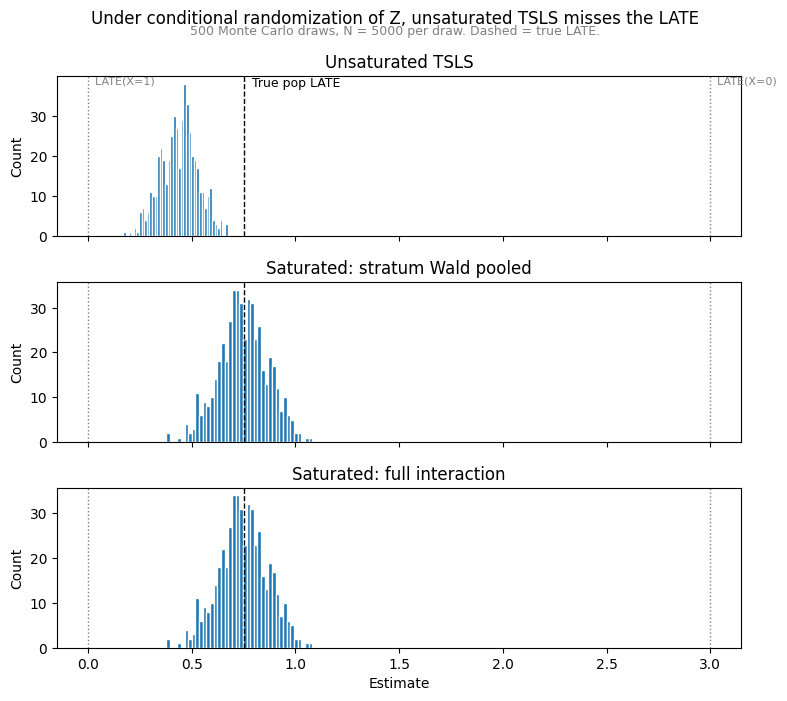

In [5]:
labels = {
    'unsat':    'Unsaturated TSLS',
    'sat_wald': 'Saturated: stratum Wald pooled',
    'full_int': 'Saturated: full interaction',
}

fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
for ax, key in zip(axes, labels):
    ax.hist(results[key], bins=40, edgecolor='white')
    ax.axvline(true_LATE, linestyle='--', color='black', linewidth=1.0)
    ax.axvline(tau_X0,    linestyle=':',  color='gray',  linewidth=1.0)
    ax.axvline(tau_X1,    linestyle=':',  color='gray',  linewidth=1.0)
    ax.set_title(labels[key])
    ax.set_ylabel('Count')

# Annotate the three reference lines on the top axis only
top = axes[0].get_ylim()[1]
axes[0].text(true_LATE, top, '  True pop LATE',   ha='left', va='top', fontsize=9)
axes[0].text(tau_X0,    top, '  LATE(X=0)',       ha='left', va='top', fontsize=8, color='gray')
axes[0].text(tau_X1,    top, '  LATE(X=1)',       ha='left', va='top', fontsize=8, color='gray')

axes[-1].set_xlabel('Estimate')
fig.suptitle('Under conditional randomization of Z, unsaturated TSLS misses the LATE',
             fontsize=12, y=0.995)
fig.text(0.5, 0.96, f'{N_SIM} Monte Carlo draws, N = {N} per draw. Dashed = true LATE.',
         ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.show()

## Punchline

When the instrument is only valid **conditional on** $X$, you cannot recover the LATE by adding $X$ as a linear control in the TSLS. The first stage must be saturated: interact $Z$ with $X$ (and $D$ with $X$ in the structural equation) so every stratum of $X$ gets its own Wald estimate, which you then aggregate by complier mass.

**Blandhol et al.'s contribution** is to make the weighting explicit: unsaturated TSLS produces a weighted average of stratum LATEs, but with weights that depend on the first-stage strength per stratum — not on the complier mass you care about. When those two diverge (as they do here by construction), TSLS is not even a positively-weighted average of LATEs.

### Reproducibility note

`numpy.random.default_rng(20260421)` differs bitwise from R's `set.seed(20260421)` (different PRNG algorithm). Qualitative pattern — unsaturated biased, both saturated unbiased — reproduces faithfully; exact numerical values do not. The retired R simulation is preserved at the `v0-r-era` git tag.